In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import numpy as np
import pandas as pd
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt

import matplotlib as mpl
mpl.rcParams.update({'font.size': 15})

from wilco.stimulus import SquareWave, PulseTrain, NonspecificStimulus, StaticWave, FenderJuleszStimulus
from wilco.model import ActiveTransientModel, OscillatoryModel, SteadyStateModel

100%|██████████| 599/599 [00:00<00:00, 1739.16it/s]


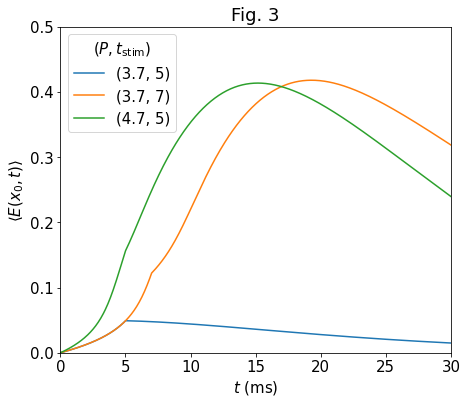

In [58]:
fig, ax = plt.subplots(figsize=(7, 6))

ax.set_title("Fig. 3")
ax.set_xlim([0, 30])
ax.set_xticks(np.arange(0, 31, 5));

ax.set_ylim([0, .5])
ax.set_yticks(np.arange(0, 0.51, .1));

for P, t in ((3.7, 5), (3.7, 7), (4.7, 5)):
    stim = SquareWave(center = 0, width=80, P = P, duration = t)
    res = ActiveTransientModel().run(xmin = -500, xmax = 500, num_nodes=1000, t_max = 30, dt = .05, P = stim)

    sns.lineplot(data = res.get(x=0), x = "t", y = "E", label=(P, t))

ax.set_xlabel(r"$t$ (ms)")
ax.set_ylabel(r"$\langle E(x_0, t) \rangle$")

ax.legend(title=r"$(P, t_\mathrm{stim})$")

100%|██████████| 599/599 [00:00<00:00, 1853.66it/s]


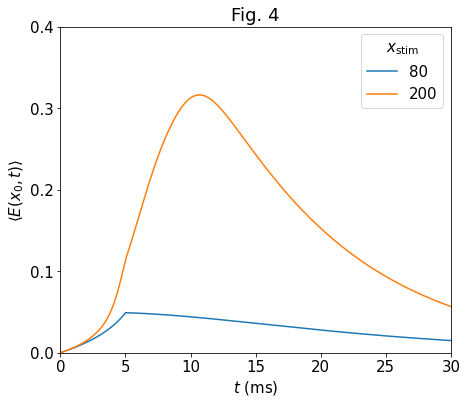

In [59]:
fig, ax = plt.subplots(figsize=(7, 6))

ax.set_title("Fig. 4")
ax.set_xlim([0, 30])
ax.set_xticks(np.arange(0, 31, 5));

ax.set_ylim([0, .4])
ax.set_yticks(np.arange(0, 0.41, .1));

for w in (80, 200):
    stim = SquareWave(center = 0, width=w, P = 3.7, duration = 5)
    res = ActiveTransientModel().run(xmin = -500, xmax = 500, num_nodes=1000, t_max = 30, dt = .05, P = stim)

    sns.lineplot(data = res.get(x=0), x = "t", y = "E", label=(w))

ax.set_xlabel(r"$t$ (ms)")
ax.set_ylabel(r"$\langle E(x_0, t) \rangle$")

ax.legend(title=r"$x_{\mathrm{stim}}$")

100%|██████████| 1199/1199 [00:01<00:00, 628.37it/s]


Text(0.5, 0.98, 'Fig. 5')

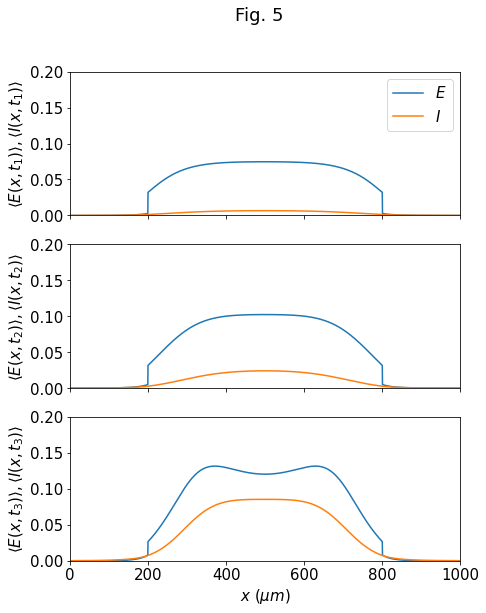

In [ ]:
fig, ax = plt.subplots(nrows = 3, figsize=(7, 9))

P, d = 3.7, 4

stim = SquareWave(P=P,center = 500, width=600, duration=d)
res = ActiveTransientModel().run(xmin = 0, xmax = 1000, num_nodes=2000, t_max = 60, dt = .05, P = stim)

ts = [d, 5, 8]

y_labels = [
    r"$\langle E(x, t_1) \rangle, \langle I(x, t_1) \rangle$",
    r"$\langle E(x, t_2) \rangle, \langle I(x, t_2) \rangle$",
    r"$\langle E(x, t_3) \rangle, \langle I(x, t_3) \rangle$"]

for i in (0, 1, 2):
    sns.lineplot(data = res.get(t=ts[i]), x = "x", y = "E", ax=ax[i], label=r"$E$")
    sns.lineplot(data = res.get(t=ts[i]), x = "x", y = "I", ax=ax[i], label=r"$I$")

    ax[i].set_xlim([0, 1000])
    ax[i].set_xticks(range(0, 1001, 200))

    if i == 2:
        ax[i].set_xlabel(r"$x\ (\mu m)$")
    if i != 2:
        ax[i].set_xlabel("")
        ax[i].set_xticklabels([])

    if i != 0:
        ax[i].get_legend().remove()

    ax[i].set_ylim([0, 0.2])

    ax[i].set_ylabel(y_labels[i])

fig.suptitle("Fig. 5")

100%|██████████| 1199/1199 [00:00<00:00, 1818.61it/s]


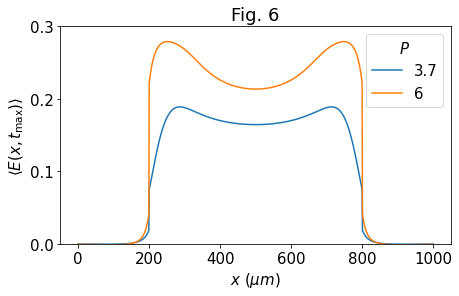

In [87]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.set_xlabel(r"$x\ (\mu m)$")
ax.set_ylabel(r"$\langle E(x, t_{\mathrm{max}})\rangle$")

ax.set_ylim([0, 0.3])
ax.set_yticks(np.arange(0, 0.31, 0.1))

ax.set_title("Fig. 6")

t_stim = 6

for P, t_max in ((3.7, 8.5), (6, 7)):
    stim = SquareWave(P=P,center = 500, width=600, duration=t_stim)
    res = ActiveTransientModel().run(xmin = 0, xmax = 1000, num_nodes=1000, t_max = 60, dt = .05, P = stim)
    sns.lineplot(data = res.get(t = t_max), x = "x", y = "E", label = P)

ax.legend(title=r"$P$")

100%|██████████| 399/399 [00:00<00:00, 1625.63it/s]


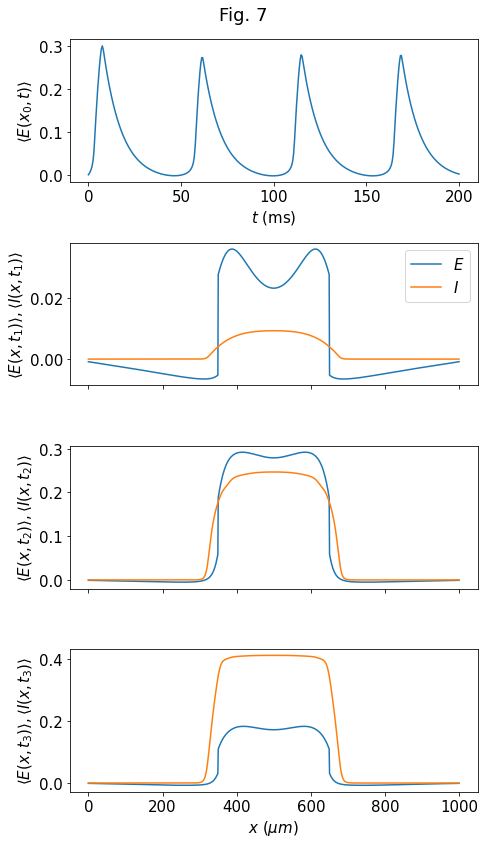

In [62]:
P = 4

stim = SquareWave(center = 500, width=300, P=P, duration=200)
res = OscillatoryModel().run(xmin = 0, xmax = 1000, num_nodes=1000, t_max = 200, dt = .5, P = stim)

fig, ax = plt.subplots(nrows = 4, figsize = (7, 12))

sns.lineplot(data = res.get(x=500), x = "t", y = "E", ax = ax[0])

for u, u_label in (("E", r"$E$"),  ("I",r"$I$")):
    sns.lineplot(data = res.get(t=110), x = "x", y = u, ax=ax[1], label=u_label)
    sns.lineplot(data = res.get(t=115), x = "x", y = u, ax=ax[2], label=u_label)
    sns.lineplot(data = res.get(t=120), x = "x", y = u, ax=ax[3], label=u_label)

y_labels = [
    r"$\langle E(x_0, t) \rangle$",
    r"$\langle E(x, t_1) \rangle, \langle I(x, t_1) \rangle$",
    r"$\langle E(x, t_2) \rangle, \langle I(x, t_2) \rangle$",
    r"$\langle E(x, t_3) \rangle, \langle I(x, t_3) \rangle$"
]

ax[0].set_xticks(np.arange(0, 201, 50))

for i in range(4):
    ax[i].set_xlabel(r"$t$ (ms)" if i == 0 else r"$x\ (\mu m)$" if i == 3 else "")
    if i >= 2:
        ax[i].get_legend().remove()

    if i in (1, 2):
        ax[i].set_xticklabels([])

    ax[i].set_ylabel(y_labels[i])

fig.suptitle("Fig. 7")
fig.tight_layout()

100%|██████████| 599/599 [00:00<00:00, 1856.43it/s]


<AxesSubplot:title={'center':'Fig. 8'}, xlabel='$t\\ (ms)$', ylabel='$\\langle E(x, t_{\\mathrm{max}})\\rangle$'>

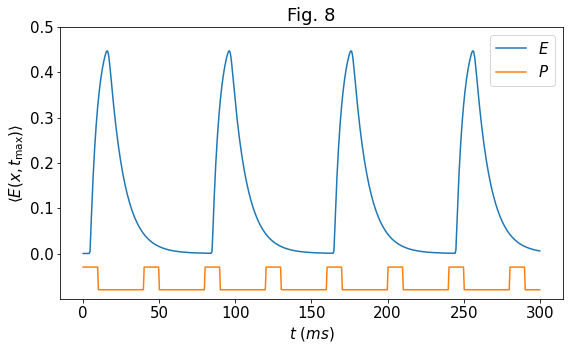

In [63]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.set_xlabel(r"$t\ (ms)$")
ax.set_ylabel(r"$\langle E(x, t_{\mathrm{max}})\rangle$")

ax.set_ylim([-.1, 0.5])
ax.set_yticks(np.arange(0, 0.51, 0.1))

ax.set_title("Fig. 8")

stim = PulseTrain(P=5,center = 500, width=80, duration=10, freq=25)
res = OscillatoryModel().run(xmin = 0, xmax = 1000, num_nodes=1000, t_max = 300, dt = .5, P = stim)
sns.lineplot(data = res.get(x = 500), x = "t", y = "I", ax=ax, label=r"$E$")

stim = res.get(x = 500)
stim["P"] *= .05 / stim["P"].max()
stim["P"] -= .08
sns.lineplot(data = stim, x = "t", y = "P", ax=ax, label = r"$P$")

100%|██████████| 599/599 [00:00<00:00, 761.86it/s]


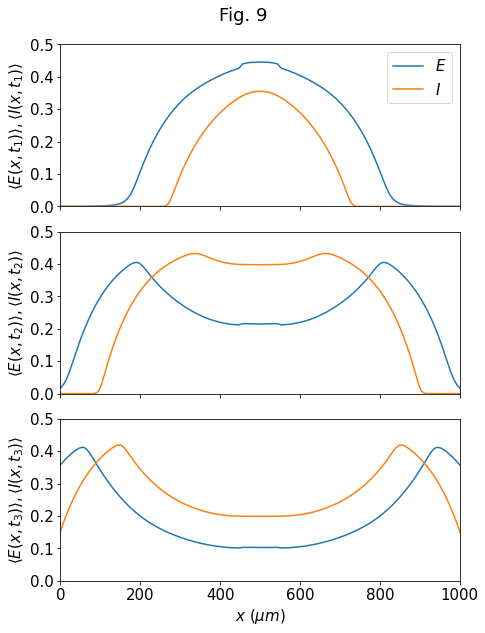

In [116]:
fig, ax = plt.subplots(nrows = 3, figsize=(7, 9))

P = SquareWave(center = 500, width=100, P=3.7, duration=5)
Q = NonspecificStimulus(a = -30)
res = OscillatoryModel().run(xmin = 500 - 2000, xmax = 500 + 2000, num_nodes=500, t_max=60, dt = .1, P = P, Q=Q)

ts = [15, 23, 30]

y_labels = [
    r"$\langle E(x, t_1) \rangle, \langle I(x, t_1) \rangle$",
    r"$\langle E(x, t_2) \rangle, \langle I(x, t_2) \rangle$",
    r"$\langle E(x, t_3) \rangle, \langle I(x, t_3) \rangle$"]
 
for i in range(3):
    sns.lineplot(data = res.get(t = ts[i]), x = "x", y = "E", label=r"$E$", ax = ax[i])
    sns.lineplot(data = res.get(t = ts[i]), x = "x", y = "I", label=r"$I$", ax = ax[i])

    ax[i].set_xlim([0, 1000])
    ax[i].set_xticks(range(0, 1001, 200))

    if i == 2:
        ax[i].set_xlabel(r"$x\ (\mu m)$")
    if i != 2:
        ax[i].set_xlabel("")
        ax[i].set_xticklabels([])

    if i != 0:
        ax[i].get_legend().remove()

    ax[i].set_ylim([0, 0.5])

    ax[i].set_ylabel(y_labels[i])

fig.suptitle("Fig. 9")
fig.tight_layout()

100%|██████████| 199/199 [00:00<00:00, 1564.57it/s]


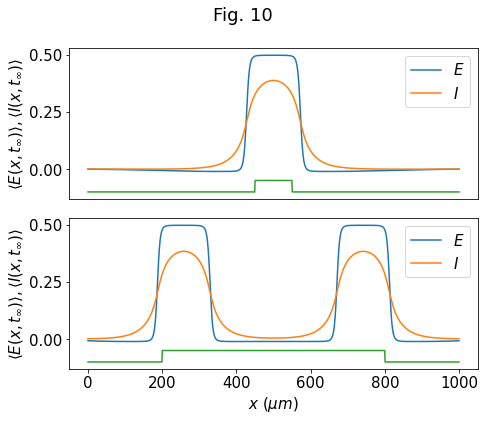

In [71]:
fig, ax = plt.subplots(nrows = 2, figsize=(7,6))

Ps = (SquareWave(center = 500, width=100, P=2, duration=10), SquareWave(center = 500, width=600, P=2, duration=10))

for i in range(2):
    res = SteadyStateModel().run(xmin = 0, xmax = 1000, num_nodes=1000, t_max=100, dt = .5, P = Ps[i])
    sns.lineplot(data = res.get(t = 100), x="x", y = "E", ax = ax[i], label=r"$E$")
    sns.lineplot(data = res.get(t = 100), x="x", y = "I", ax = ax[i], label=r"$I$")

    stim = res.get(t = 0)
    stim["P"] *= .05 / stim["P"].max()
    stim["P"] -= .1
    
    sns.lineplot(data = stim, x = "x", y = "P", ax = ax[i])

    ax[i].set_xlabel(r"$x\ (\mu m)$" if i == 1 else "")
    ax[i].set_xticks(np.arange(0, 1001, 200) if i == 1 else [])
    ax[i].set_ylabel(r"$\langle E(x, t_{\infty}) \rangle, \langle I(x, t_{\infty}) \rangle$")
    ax[i].set_yticks([0, 0.25, 0.5])

fig.suptitle("Fig. 10")
fig.tight_layout()

  0%|          | 0/199 [00:00<?, ?it/s]

100%|██████████| 199/199 [00:00<00:00, 1694.75it/s]


<AxesSubplot:xlabel='Stimulus frequency (cycles/mm)', ylabel='$\\langle E_{\\mathrm{max}}\\rangle - \\langle E_{\\mathrm{min}}\\rangle$'>

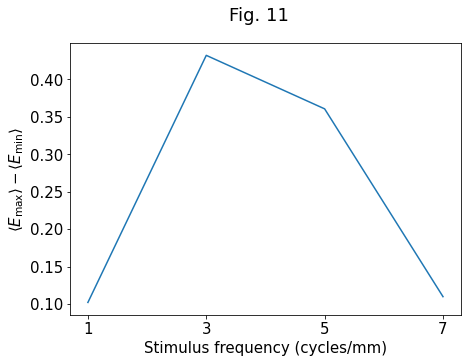

In [117]:
curve = []

for n in range(1, 8, 2):
    P = StaticWave(amplitude=4.5, n = n, L = 1000,  duration=5)
    res = ActiveTransientModel().run(xmin = 0, xmax = 1000, num_nodes=1000, t_max=20, dt = .1, P = P)

    idx_t = np.argmax(np.max(res.E, axis=1) - np.min(res.E, axis=1))
    E_max = res.E[idx_t].max()
    E_min = res.E[idx_t].min()

    curve.append([n, E_max - E_min])

curve = pd.DataFrame(curve, columns = ["freq", "amp"])

fig, ax = plt.subplots(figsize=(7, 5))

ax.set_xlabel("Stimulus frequency (cycles/mm)")
ax.set_xticks(range(1, 8, 2))

ax.set_ylabel(r"$\langle E_{\mathrm{max}}\rangle - \langle E_{\mathrm{min}}\rangle$")

fig.suptitle("Fig. 11")

sns.lineplot(data=curve, x = "freq", y ="amp")

100%|██████████| 89/89 [00:00<00:00, 1795.51it/s]


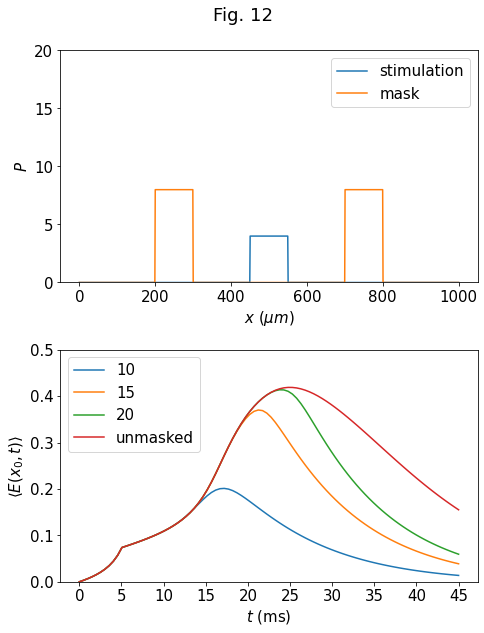

In [118]:
width = 100
amp = 4
alpha = 2
duration = 5
offset = 150

fig, ax = plt.subplots(figsize=(7, 9), nrows = 2)

for t in (10, 15, 20, 100):
    P = SquareWave(center = 500, width = width, P = amp, duration = duration)
    P_mask = SquareWave(center = 500 - width - offset, width = width, duration=duration, start = t, P = alpha*amp) + SquareWave(center = 500 + width + offset, width = width, duration=duration, start = t, P = alpha*amp)

    res = ActiveTransientModel().run(xmin = 0, xmax = 1000, num_nodes=1000, t_max=45, dt = .5, P = P+P_mask)

    sns.lineplot(data = res.get(x = 500), x = "t", y = "E", label="unmasked" if t==100 else t, ax=ax[1])

    if t == 10:
        sns.lineplot(data = res.get(t = 0), x = "x", y = "P", ax=ax[0], label = "stimulation")
        sns.lineplot(data = res.get(t = 10), x = "x", y = "P", ax=ax[0], label = "mask")


ax[0].set_ylim([0, 20])
ax[0].set_xlabel(r"$x\ (\mu m)$")
ax[0].set_ylabel(r"$P$")

ax[1].set_xlabel(r"$t$ (ms)")
ax[1].set_xticks(range(0,46,5));

ax[1].set_ylim([0, 0.5])
ax[1].set_yticks(np.arange(0, 0.51, 0.1))
ax[1].set_ylabel(r"$\langle E(x_0, t)\rangle$")

fig.suptitle("Fig. 12")
fig.tight_layout()

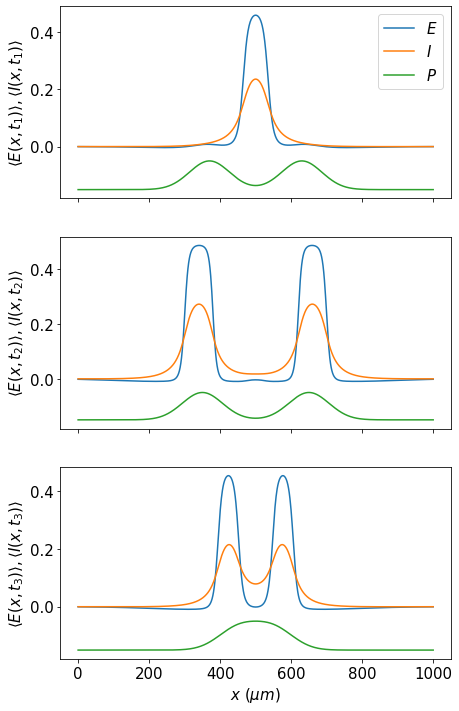

In [ ]:
res = ActiveTransientModel().run(xmin = 0, xmax = 1000, num_nodes=1000, t_max=2500, dt = .1, P = FenderJuleszStimulus(center=500, k=3.7, v=10, sigma=80, delay=100, turnaround=200), dtype="float64")

fig, ax = plt.subplots(nrows = 3, figsize = (7, 12))

ts = [1300, 1500, 3600]

y_labels = [
    r"$\langle E(x, t_1) \rangle, \langle I(x, t_1) \rangle$",
    r"$\langle E(x, t_2) \rangle, \langle I(x, t_2) \rangle$",
    r"$\langle E(x, t_3) \rangle, \langle I(x, t_3) \rangle$"]

for i in range(3):
    sns.lineplot(data = res.get(t=ts[i]), x = "x", y = "E", ax=ax[i], label=r"$E$")
    sns.lineplot(data = res.get(t=ts[i]), x = "x", y = "I", ax=ax[i], label=r"$I$")

    stim = res.get(t = ts[i])
    stim["P"] *= .1 / stim["P"].max()
    stim["P"] -= .15

    sns.lineplot(data = stim, x = "x", y = "P", label = r"$P$", ax=ax[i])

    ax[i].set_ylabel(y_labels[i])

    if i != 0:
        ax[i].get_legend().remove()

    if i == 2:
        ax[i].set_xlabel(r"$x\ (\mu m)$")
    else:
        ax[i].set_xlabel("")
        ax[i].set_xticklabels([])